# simulation validation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import scipy
import numpy as np
from pprint import pprint
import pickle
import heapq
from collections import deque
from tqdm import tqdm
import functools
import operator

In [2]:
# import master df
master_df = pd.read_csv(r'.\data\processed_oct_Data.csv')
blue = master_df[master_df['route_id']=='Blue']
blue = blue[['stop_name', 'route_id', 'move_timestamp', 'vehicle_id',
            'travel_time_seconds', 'dwell_time_seconds', 'headway_trunk_seconds',
            'direction_id', 'direction_destination',
            'scheduled_travel_time', 'scheduled_headway_trunk']]

C:\Users\prade\AppData\Local\Temp\ipykernel_21988\1526707701.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv(r'.\data\processed_oct_Data.csv')


In [5]:
cutoff_std = 2  # number of standard deviations above the mean to use as cutoff

masks = []

for station in blue['stop_name'].unique():
    # Isolate data for the current station
    station_mask = blue['stop_name'] == station
    station_data = blue[station_mask]
    
    # Compute upper cutoff for travel and dwell time (mean + n*std)
    travel_cutoff = station_data['travel_time_seconds'].mean() + cutoff_std * station_data['travel_time_seconds'].std()
    dwell_cutoff  = station_data['dwell_time_seconds'].mean()  + cutoff_std * station_data['dwell_time_seconds'].std()
    
    # Build mask: keep rows within cutoff for both travel and dwell time
    masks.append(
        station_mask &
        (blue['travel_time_seconds'] < travel_cutoff) &
        (blue['dwell_time_seconds']  < dwell_cutoff)
    )

# Combine station masks with OR and apply to filter the dataframe
blue = blue[functools.reduce(operator.or_, masks)]

In [6]:
# Ordered list of Blue Line stops from Bowdoin (western terminus) to Wonderland (eastern terminus)
blue_stops = ['Bowdoin', 'Government Center', 'State', 'Aquarium',
              'Maverick', 'Airport', 'Wood Island',
              'Orient Heights', 'Suffolk Downs', 
              'Beachmont', 'Revere Beach', 'Wonderland']

stops_df = pd.DataFrame({'stop_name': blue_stops})

# Inbound direction (false): each station's next stop is the one ahead in the list
stops_df['fromstation_false'] = stops_df['stop_name'].shift(-1)
# Wonderland has no next stop — wraps back to Revere Beach as terminus boundary
stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'

# Outbound direction (true): each station's previous stop is the one behind in the list
stops_df['fromstation_true'] = stops_df['stop_name'].shift(1)
# Bowdoin has no previous stop — wraps to Government Center as terminus boundary
stops_df['fromstation_true'].iloc[0] = 'Government Center'

# Index by stop name for fast lookup when mapping travel times
stops_df.set_index('stop_name', inplace=True)

C:\Users\prade\AppData\Local\Temp\ipykernel_11644\3176432345.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  stops_df['fromstation_false'].iloc[-1] = 'Revere Beach'
C:\Users\prade\AppData\Local\Temp\ipykernel_11644\3176432345.py:17: Fut

In [7]:
'''
Map each trip's origin station based on direction:
direction_id=True (outbound) → use fromstation_true (previous stop in list)
direction_id=False (inbound) → use fromstation_false (next stop in list)
'''
blue['fromstation'] = blue.apply(lambda x: stops_df['fromstation_true'][x['stop_name']]
                                             if x['direction_id']
                                            else stops_df['fromstation_false'][x['stop_name']],
                                            axis=1)

In [8]:
blue['move_timestamp'] = pd.to_datetime(blue['move_timestamp'])

In [18]:
def dist(timetable):
    temp1 = timetable[timetable['station']=='Wonderland'].sort_values(['train_id','station'])['departure'].diff()/60
    temp1 =temp1[temp1>0]
    sns.histplot(temp1, alpha=0.5)
    print(temp1.mean().item(), np.percentile(temp1, 10).item(), np.percentile(temp1, 90).item())
    return temp1


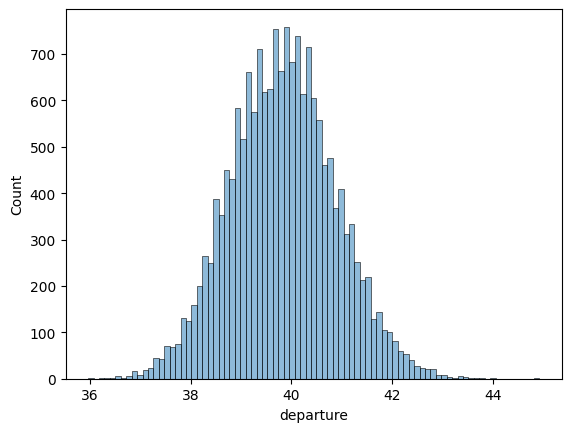

In [ ]:
timetable = pd.read_csv(r'.\data\blue_timetable.csv')
gamma = dist(timetable)

In [17]:
gamma.mean().item(), np.percentile(gamma, 10).item(), np.percentile(gamma, 90).item()

(39.830780202948496, 38.516666666666666, 41.18333333333333)

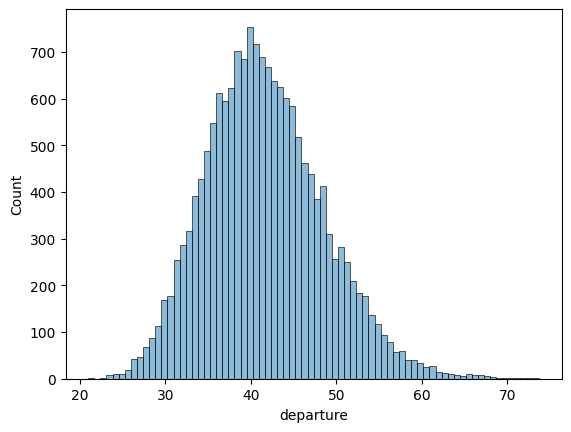

In [11]:
timetable = pd.read_csv(r'.\data\blue_timetable.csv')
expo = dist(timetable)

In [19]:
expo.mean().item(), np.percentile(expo, 10).item(), np.percentile(expo, 90).item()

(41.62698193326123, 33.18333333333333, 50.78333333333333)

38.86065838323912 37.833333333333336 39.916666666666664


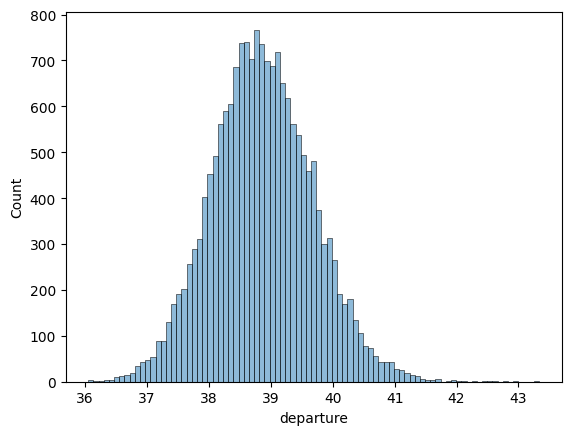

In [21]:

timetable = pd.read_csv(r'.\data\blue_timetable.csv')
fisk = dist(timetable)

39.267987891133366 37.1 41.46666666666667


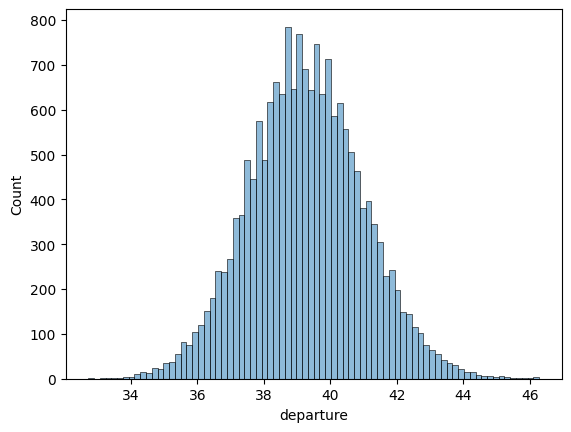

In [22]:

timetable = pd.read_csv(r'.\data\blue_timetable.csv')
weibull_min = dist(timetable)


39.69010559621836 38.46666666666667 40.96666666666667


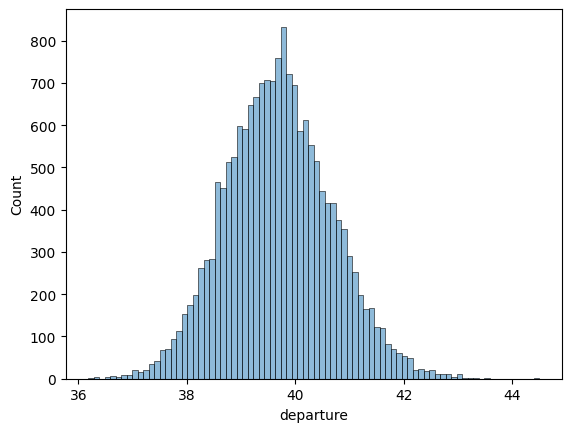

In [23]:

timetable = pd.read_csv(r'.\data\blue_timetable.csv')
lognorm = dist(timetable)


39.42313878154126 38.31666666666667 40.583333333333336


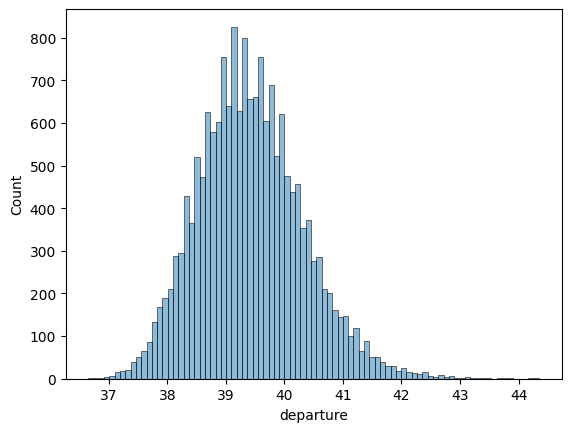

In [24]:

timetable = pd.read_csv(r'.\data\blue_timetable.csv')
burr = dist(timetable)


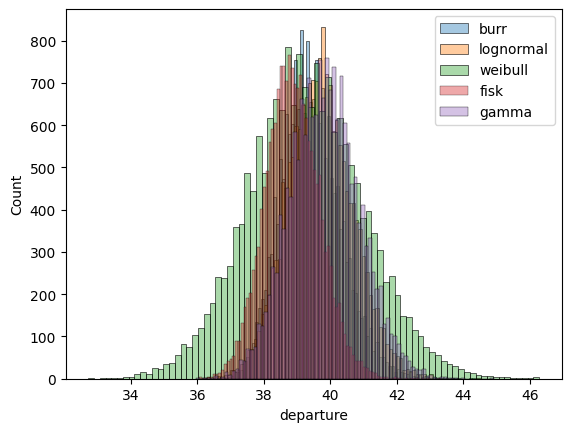

In [27]:
sns.histplot(burr,alpha=0.4, label='burr')
sns.histplot(lognorm,alpha=0.4, label='lognormal')
sns.histplot(weibull_min,alpha=0.4, label='weibull')
sns.histplot(fisk,alpha=0.4, label='fisk')
# sns.histplot(expo,alpha=0.4, label='exponential')
sns.histplot(gamma,alpha=0.4, label='gamma')

plt.legend()

In [ ]:
df = pd.read_csv(r'Cell 22.csv')

In [ ]:
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df['trains'].values.reshape(-1, 1)
y = df['delay'].values
# Linear
lr = LinearRegression().fit(X, y)
print("Linear R²:", r2_score(y, lr.predict(X)))

# Polynomial degree 2
pf = PolynomialFeatures(degree=2)
lr2 = LinearRegression().fit(pf.fit_transform(X), y)
print("Poly R²:", r2_score(y, lr2.predict(pf.fit_transform(X))))


Linear R²: 0.9431075911643283
Poly R²: 0.9932958770816529
Poly R3: 0.9933091041863898


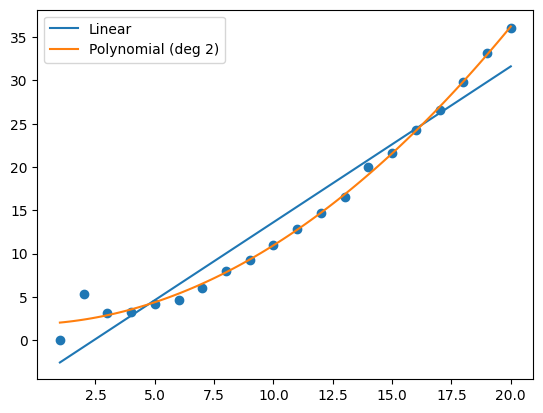

In [32]:
import numpy as np
import matplotlib.pyplot as plt

x = df['trains'].values
y = df['delay'].values

# Fit linear and polynomial
linear = np.polyfit(x, y, 1)
poly = np.polyfit(x, y, 2)

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, np.polyval(linear, x_line), label="Linear")
plt.plot(x_line, np.polyval(poly, x_line), label="Polynomial (deg 2)")
plt.scatter(x, y)
plt.legend()
plt.show()

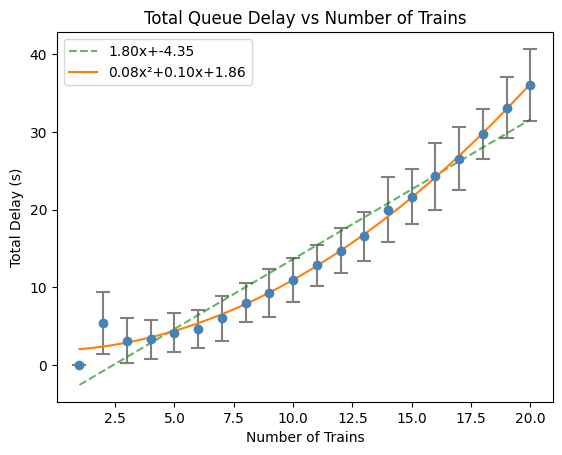

In [58]:
x = df["trains"]
y = df["delay"]
yerr = df["std"]  # or your error/confidence interval column

plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=5, capthick=1.5, 
             elinewidth=1.5, markersize=6, color='steelblue', ecolor='grey')
plt.plot(x_line, np.polyval(linear, x_line),'--g', label=f"{linear[0]:.2f}x+{linear[1]:.2f}", alpha=0.6)
plt.plot(x_line, np.polyval(poly, x_line), label=f"{poly[0]:.2f}x²+{poly[1]:.2f}x+{poly[2]:.2f}", color='tab:orange')

plt.xlabel("Number of Trains")
plt.ylabel("Total Delay (s)")
plt.title("Total Queue Delay vs Number of Trains")
plt.legend()
plt.show()

In [43]:
poly.round(2)

array([0.08, 0.1 , 1.86])

In [42]:
linear

array([ 1.79849624, -4.35421053])